In [ ]:
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic


load_dotenv()

llm = ChatAnthropic(
    model= 'claude-sonnet-4-20250514',
    temperature= '0.1'
)

# claude-opus-4-5-20251101
# claude-sonnet-4-5-20250929
# claude-haiku-4-5-20251001

In [ ]:
query = '대손충당금에 대해서 설명해주세요'

In [19]:
from typing import Annotated                # 메타데이터(langgraph가 받을) 다는 라이브러리
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [20]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [21]:
def generate(state: AgentState) -> AgentState:
    messages = state['messages']
    ai_message = llm.invoke(messages)
    return {'messages': [ai_message]}

graph_builder.add_node('generate', generate)

In [22]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

In [23]:
graph = graph_builder.compile()

In [24]:
from langchain_core.messages import HumanMessage

initial_state = {'messages': [HumanMessage(query)]}

In [25]:
graph.invoke(initial_state)

{'messages': [HumanMessage(content='원천징수되는 기타소득에 관하여 설명하시오', additional_kwargs={}, response_metadata={}, id='7e76a191-af87-412f-b35c-a72ac5c8c354'),
  AIMessage(content='# 원천징수되는 기타소득\n\n## 1. 기타소득의 개념\n기타소득은 이자소득, 배당소득, 사업소득, 근로소득, 연금소득, 퇴직소득, 양도소득, 산림소득에 해당하지 않는 소득으로서 일시적·우발적 성격을 가진 소득을 말합니다.\n\n## 2. 원천징수 대상 기타소득의 종류\n\n### 가. 상금, 현상금, 포상금\n- 경품권, 복권당첨금\n- 각종 경기대회 상금\n- 현상공모 당첨금\n\n### 나. 강연료, 원고료\n- 강의료, 강연료\n- 원고료, 인세\n- 방송출연료\n\n### 다. 인적용역 제공대가\n- 일회성 또는 단발성 용역제공 대가\n- 전문직 자문료\n- 심사료, 감정료\n\n### 라. 기타\n- 사례금\n- 노하우 제공대가\n- 공익신고 포상금\n\n## 3. 원천징수세율\n\n### 가. 일반세율\n- **20%** (지방소득세 2% 별도)\n- 총 **22%** 원천징수\n\n### 나. 특별세율 적용 대상\n- **복권당첨금**: 22% (300만원 초과분)\n- **경품권**: 22% (6만원 초과분)\n- **강연료 등**: 8.8% (건당 50만원 이하)\n\n## 4. 원천징수 방법\n\n### 가. 원천징수 시기\n- 기타소득을 지급하는 때\n- 지급일이 속하는 달의 다음 달 10일까지 신고·납부\n\n### 나. 필요경비 공제\n- **60% 필요경비율** 적용 (일부 소득 제외)\n- 실제 필요경비가 더 큰 경우 실제 필요경비 적용 가능\n\n### 다. 계산 예시\n```\n지급액 100만원인 경우:\n- 필요경비: 100만원 × 60% = 60만원\n- 과세표준: 100만원 - 60만원 = 40만원\n- 원천징수세액: 40

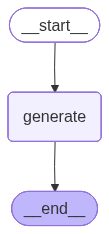

In [ ]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

## 데이터 전처리

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
import nest_asyncio
nest_asyncio.apply()

In [ ]:
from pyzerox import zerox
import os
import asyncio
from dotenv import load_dotenv

load_dotenv()


model = "claude-sonnet-4-20250514"
custom_system_prompt = None

async def main():
    file_path = "Tax.pdf"
    select_pages = None  # 전체 페이지
    output_dir = "./output_test"
    
    result = await zerox(
        file_path=file_path,
        model=model,
        output_dir=output_dir,
        custom_system_prompt=custom_system_prompt,
        select_pages=select_pages
    )
    return result

# 실행
result = asyncio.run(main())
print(result)

## Retrieve

In [2]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma
from langchain_community.document_loaders import Docx2txtLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
import shutil

# 1. 문서 로드
loader = Docx2txtLoader('Tax_with_table.docx')
documents = loader.load()

# 2. 텍스트 분할 (청킹)
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)
splits = text_splitter.split_documents(documents)

In [13]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma

embedding = UpstageEmbeddings(model="solar-embedding-1-large")


# database = Chroma.from_documents(
#     documents=splits,
#     embedding=embedding,
#     collection_name='chroma-tax',
#     persist_directory='./preprocessed-upstage'
# )


database = Chroma(
  collection_name= 'chroma-tax',
  persist_directory= './preprocessed-upstage',
  embedding_function= embedding     
)

In [14]:
retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 10,                # chunk_size 고려해서 조정 - 추후 context history까지 관리해야 함
        'fetch_k': 50,          # 나중엔 동적 k / 히스토리 요약으로 구현하고 싶음
        'lamda_mult': 0.6       # simility와 가까운 수준(mmr에서)
    }
)

In [12]:
query = '원천징수되는 기타소득에 관하여 설명하시오'

retriever.invoke(query)

[Document(metadata={'source': 'Tax_with_table.docx'}, page_content='② 원천징수의무자가 12월분의 연말정산 사업소득을 다음 연도 2월 말일까지 지급하지 아니한 경우에는 다음 연도 2월 말일에 그 사업소득을 지급한 것으로 보아 소득세를 원천징수한다.\n\n[본조신설 2010. 12. 27.]\n\n\n\n제5관 기타소득에 대한 원천징수 <개정 2009. 12. 31.>\n\n\n\n제145조(기타소득에 대한 원천징수시기와 방법 및 원천징수영수증의 발급) ① 원천징수의무자가 기타소득을 지급할 때에는 그 기타소득금액에 원천징수세율을 적용하여 계산한 소득세를 원천징수한다.\n\n② 기타소득을 지급하는 원천징수의무자는 이를 지급할 때에 그 기타소득의 금액과 그 밖에 필요한 사항을 적은 재정경제부령으로 정하는 원천징수영수증을 그 소득을 받는 사람에게 발급하여야 한다. 다만, 제21조제1항제15호가목 및 제19호가목ㆍ나목에 해당하는 기타소득으로서 대통령령으로 정하는 금액 이하를 지급할 때에는 지급받는 자가 원천징수영수증의 발급을 요구하는 경우 외에는 발급하지 아니할 수 있다.<개정 2010. 12. 27., 2025. 10. 1.>\n\n[전문개정 2009. 12. 31.]\n\n[제목개정 2010. 12. 27.]\n\n\n\n제145조의2(기타소득 원천징수시기에 대한 특례) 「법인세법」 제67조에 따라 처분되는 기타소득에 대한 소득세의 원천징수시기에 관하여는 제131조제2항을 준용한다.\n\n[본조신설 2010. 12. 27.]\n\n\n\n제145조의3(종교인소득에 대한 연말정산 등) ① 종교인소득을 지급하고 그 소득세를 원천징수하는 자는 해당 과세기간의 다음 연도 2월분의 종교인소득을 지급할 때(2월분의 종교인소득을 2월 말일까지 지급하지 아니하거나 2월분의 종교인소득이 없는 경우에는 2월 말일로 한다. 이하 이 조에서 같다) 또는 해당 종교관련종사자와의 소속관계가 종료되는 달의 종교인소득을 지급할 때 해당 과세

## RAG Chain with Node, Edge

In [54]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document


class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [68]:
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langsmith import Client

load_dotenv()


client = Client()
prompt = client.pull_prompt("rlm/rag-prompt")

llm = ChatAnthropic(
    model= 'claude-sonnet-4-20250514',
    temperature= '0.1'
)

# claude-opus-4-5-20251101
# claude-sonnet-4-5-20250929
# claude-haiku-4-5-20251001

In [69]:
def retrieve(state: AgentState):
    query  = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

In [77]:
def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = prompt | llm
    response = rag_chain.invoke({'context': context, 'question': query})
    return {'answer': response}

In [78]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [79]:
from langgraph.graph import START, END

graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

In [80]:
graph = graph_builder.compile()

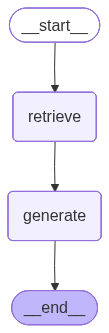

In [81]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

## RAG Chain with Sequence

In [93]:
sequence_graph_builder = StateGraph(AgentState).add_sequence([retrieve, generate])

In [ ]:
sequence_graph_builder.add_edge(START, 'retrieve')      # add_sequence에서 함수 이름으로 Node를 만들어놓고 그 사이의 edge도 그어줌
sequence_graph_builder.add_edge('generate', END)

In [95]:
graph = sequence_graph_builder.compile()

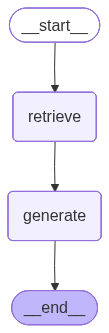

In [96]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [98]:
query = '8000만원에 매도한 서화가 기타소득 과세 대상인지 알려줘'
initial_state = {'query': query}
graph.invoke(initial_state)

{'query': '8000만원에 매도한 서화가 기타소득 과세 대상인지 알려줘',
 'context': [Document(metadata={'source': 'Tax_with_table.docx'}, page_content='다. 변호사, 공인회계사, 세무사, 건축사, 측량사, 변리사, 그 밖에 전문적 지식 또는 특별한 기능을 가진 자가 그 지식 또는 기능을 활용하여 보수 또는 그 밖의 대가를 받고 제공하는 용역\n\n라. 그 밖에 고용관계 없이 수당 또는 이와 유사한 성질의 대가를 받고 제공하는 용역\n\n20. 「법인세법」 제67조에 따라 기타소득으로 처분된 소득\n\n21. 제20조의3제1항제2호나목 및 다목의 금액을 그 소득의 성격에도 불구하고 연금외수령한 소득\n\n22. 퇴직 전에 부여받은 주식매수선택권을 퇴직 후에 행사하거나 고용관계 없이 주식매수선택권을 부여받아 이를 행사함으로써 얻는 이익\n\n22의2. 종업원등 또는 대학의 교직원이 퇴직한 후에 지급받는 직무발명보상금\n\n23. 뇌물\n\n24. 알선수재 및 배임수재에 의하여 받는 금품\n\n25. 삭제<2020. 12. 29.>\n\n26. 종교관련종사자가 종교의식을 집행하는 등 종교관련종사자로서의 활동과 관련하여 대통령령으로 정하는 종교단체로부터 받은 소득(이하 “종교인소득”이라 한다)\n\n② 제1항 및 제19조제1항제21호에도 불구하고 대통령령으로 정하는 서화(書畵)ㆍ골동품의 양도로 발생하는 소득(사업장을 갖추는 등 대통령령으로 정하는 경우에 발생하는 소득은 제외한다)은 기타소득으로 한다.<신설 2020. 12. 29.>\n\n③ 기타소득금액은 해당 과세기간의 총수입금액에서 이에 사용된 필요경비를 공제한 금액으로 한다.<개정 2020. 12. 29.>\n\n④ 제1항제26호에 따른 종교인소득에 대하여 제20조제1항에 따른 근로소득으로 원천징수하거나 과세표준확정신고를 한 경우에는 해당 소득을 근로소득으로 본다.<신설 2015. 12. 15., 2020. 12. 29.>\n\n⑤ 기타소득